In [2]:
import sys
import os
sys.path.append(os.path.abspath(os.pardir))

import uuid
from copy import deepcopy
from typing import Literal
from overview import FigureType, feature_overview

import numpy as np
import pandas as pd
import sklearn.preprocessing as pre
from sklearn.pipeline import make_pipeline

from processors import temparature, season, month
from transforming import (
    Apply, Bins, Calc, Fill, Group, KeepDataframe, Lag, Select, Swap,
    TypeRecast, WithSelected,
    boruta
)

# modeling dependencies
# from xgboost import XGBClassifier
# from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, f1_score, roc_auc_score
import matplotlib.pyplot as plt


def checkup(estimator_base, X, y, folds=7):
    metrics = []
    # kf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=19)
    kf = KFold(n_splits=folds, shuffle=True, random_state=19)
    estimator = estimator_base
    for f, (train, valid) in enumerate(kf.split(X, y)):
        estimator = deepcopy(estimator_base)
        estimator.fit(X.loc[train], y[train])

        pt = estimator.predict_proba(X.loc[train]).T[1]
        pv = estimator.predict_proba(X.loc[valid]).T[1]

        auc_train = roc_auc_score(y[train], pt)
        auc_valid = roc_auc_score(y[valid], pv)
        f1_train = f1_score(y[train], pt > 0.5)
        f1_valid = f1_score(y[valid], pv > 0.5)
        metrics.append((auc_train, f1_train, auc_valid, f1_valid))
        print(f'Fold: {f}; TRAIN ROC AUC={auc_train:.5f}; TRAIN f1={f1_train:.5f} | VALID ROC AUC={auc_valid:.5f}; VALID f1={f1_valid:.5f}')
    means = np.mean(metrics, axis=0)
    print(f'MEAN: TRAIN ROC AUC={means[0]:.5f}; TRAIN f1={means[1]:.5f} | VALID ROC AUC={means[2]:.5f}; VALID f1={means[3]:.5f}')
    return estimator


def linear_feature_importances(estimator, **kwargs):
    index = (-estimator.coef_).argsort()
    values = estimator.coef_[:, *index]
    labels = estimator.feature_names_in_[index.squeeze()]
    fig, ax = plt.subplots(**kwargs)
    ax.imshow(values, cmap='Blues')
    ax.set_xticks(range(len(labels)), labels=labels, rotation=90)
    plt.show()


df = pd.read_csv('data/train.csv', index_col='id')
# load original dataset
original = pd.read_csv('data/rainfall.csv').drop(59).reset_index(drop=True)
original.columns = original.columns.str.strip()
original.day = original.index.values + 1
original.rainfall = original.rainfall.apply(lambda value: int(value == 'yes'))
# fill_values = original[df.columns].mean()
df = pd.concat([df[df.columns], original[df.columns]]).reset_index(drop=True)
# load test part
test = pd.read_csv('data/test.csv', index_col='id')
test['rainfall'] = 0
CLASS_WEIGHTS = df.rainfall.value_counts() / df.shape[0]

__Pipelines__

In [109]:
ORIGIN = df.columns.to_list()
TEMPERATURES = ['mintemp', 'temparature', 'maxtemp']
_TEMPERATURES = ['_mintemp', '_temparature', '_maxtemp']


base_pipe = (
    # fix temperatures
    WithSelected(TEMPERATURES, prefix='')(
        Calc(lambda x: x.min(), to='_mintemp'),
        Calc(lambda x: x.max(), to='_maxtemp'),
        Calc(temparature, to='_temparature'),
    ),
    Select(TEMPERATURES, mode='drop'),

    # trigonometric
    Calc('np.sin(2 * np.pi * day / 365)', to='sin_day'),
    Calc('np.cos(2 * np.pi * day / 365)', to='cos_day'),
    Calc('np.sin(2 * np.pi * winddirection / 360)', to='sin_winddirection'),
    Calc('np.cos(2 * np.pi * winddirection / 360)', to='cos_winddirection'),

    # Calc('2 ** (np.sin(2 * np.pi * day / 365) * np.cos(2 * np.pi * day / 365))', to='tg_day'),
    # Calc('2 ** (np.sin(2 * np.pi * winddirection / 360) * np.cos(2 * np.pi * winddirection / 360))', to='tg_winddirection'),
    # Calc('np.sin(2 * np.pi * day / 365) * np.cos(2 * np.pi * day / 365)', to='tg_day'),
    # Calc('np.sin(2 * np.pi * winddirection / 360) * np.cos(2 * np.pi * winddirection / 360)', to='tg_winddirection'),


    # simple features
    # Calc('_maxtemp - _mintemp', 'delta_temp'),
    # Calc('dewpoint / _temparature', 'dewpoint_rate'),
    # Calc('sunshine / _temparature', 'sunshine_div_temparature'),
    Calc('cloud / humidity', to='cloud_div_humidity'),
    Calc('windspeed * sin_winddirection * cos_winddirection', to='windspeed_mul_sincos_winddirection'),
    # Calc('cloud * windspeed', to='cloud_mul_windspeed'),
    # Calc('humidity * cloud', to='humidity_mul_cloud'),
    Calc('humidity * sunshine', to='humidity_mul_sunshine'),
    # Calc('cloud / (sunshine + 1e-5)', to='cloud_div_sunshine'),
    # Calc('sunshine / (sunshine + cloud)', to='sunshine_rate'),

    # logarithmic
    # Calc('np.log(1 + windspeed * (1 + sin_winddirection * cos_winddirection))', to='log_windspeed_mul_sincos_winddirection'),
    # Calc('np.log(1 + cloud * windspeed)', to='log_cloud_mul_windspeed'),
    # Calc('np.log(1 + humidity * cloud)', to='log_humidity_mul_cloud'),
    # Calc('np.log(1 + humidity * sunshine)', to='log_humidity_mul_sunshine'),
    # Calc('np.log(1 + cloud / (sunshine + 1e-5))', to='log_cloud_div_sunshine'),

    # categories
    # Calc(month, to='ct_month'),
    Calc(season, to='ct_season'),
    # Bins('cloud', to='ct_cloud', bins=10, as_='code'),
    Bins('humidity', to='ct_humidity', bins=20, as_='code'),
    # Bins('sunshine', to='ct_sunshine', bins=10, as_='code'),

    # statistics on categories
    # WithSelected(r'(?!day|ct_(?!month)|mean_).*')(Group('ct_month', 'mean', prefix='mean_ct_month_', include_target=False)),
    # WithSelected(r'(?!day|ct_(?!season)|mean_).*')(Group('ct_season', 'mean', prefix='mean_ct_season_', include_target=False)),

    # rainfall statistics
    # WithSelected(['day'])(Group('day', 'median', prefix='median_day_', include_target=True)),
    # WithSelected(['day'])(Group('day', 'mean', prefix='mean_day_', include_target=True)),
    # NOTE these following 3 features are logically incorrect: test df has values that are not present in train df
    # WithSelected(['cloud'])(Group('cloud', 'mean', prefix='mean_cloud_', include_target=True)),
    # WithSelected(['humidity'])(Group('humidity', 'mean', prefix='mean_humidity_', include_target=True)),
    # WithSelected(['sunshine'])(Group('sunshine', 'mean', prefix='mean_sunshine_', include_target=True)),

    # WithSelected(['ct_cloud'])(Group('ct_cloud', 'mean', prefix='mean_ct_cloud_', include_target=True)),
    # WithSelected(['ct_humidity'])(Group('ct_humidity', 'mean', prefix='mean_ct_humidity_', include_target=True)),
    # WithSelected(['ct_sunshine'])(Group('ct_sunshine', 'mean', prefix='mean_ct_sunshine_', include_target=True)),

    # WithSelected(r'(?!ct_|mean_|median_)')(Group('day', 'median', prefix='median_day_', include_target=False)),
    # WithSelected(r'(?!day|ct_(?!cloud)|mean_|median_)')(Group('ct_cloud', 'median', prefix='median_ct_cloud_', include_target=False)),
    # WithSelected(r'(?!day|ct_(?!humidity)|mean_|median_)')(Group('ct_humidity', 'median', prefix='median_ct_humidity_', include_target=False)),

    WithSelected(r'(?!ct_|mean_|median_)')(Group('day', 'mean', prefix='mean_day_', include_target=False)),
    # WithSelected(r'(?!ct_|mean_)')(Group('day', 'mean', prefix='mean_day_', include_target=True)),
    # WithSelected(r'(?!day|ct_(?!cloud)|mean_|median_)')(Group('ct_cloud', 'mean', prefix='mean_ct_cloud_', include_target=True)),
    WithSelected(r'(?!day|ct_(?!humidity)|mean_|median_)')(Group('ct_humidity', 'mean', prefix='mean_ct_humidity_', include_target=True)),
    # WithSelected(r'(?!day|ct_(?!sunshine)|mean_|median_)')(Group('ct_sunshine', 'mean', prefix='mean_ct_sunshine_', include_target=True)),


    # WithSelected(['ct_sunshine', 'ct_humidity', 'ct_cloud'])(
    # WithSelected(r'(?!day|ct_(?!sunshine|humidity|cloud)|mean_|median_)')(
    #     Group(['ct_sunshine', 'ct_humidity', 'ct_cloud'], 'median', prefix='median_ct_complex_', include_target=True)
    # ),

    # previous days
    # WithSelected(['humidity', 'cloud', 'sunshine'], prefix='lag1_mean_')(Lag(1, 'mean')),
    # WithSelected(['humidity', 'cloud', 'sunshine'], prefix='lag2_mean_')(Lag(2, 'mean')),
    # WithSelected(['humidity', 'cloud', 'sunshine'], prefix='lag3_mean_')(Lag(3, 'mean')),
    # WithSelected(['sunshine', 'cloud'], prefix='last_3days_mean_')(Lag(3, 'mean')),
    # WithSelected(['sunshine'], prefix='yesterday_')(Lag(1, 'mean')),
    # WithSelected(['sunshine'], prefix='last_3days_mean_')(Lag(3, 'mean')),

    # Calc('yesterday_cloud - cloud', to='delta_cloud'),
    # Calc('yesterday_sunshine - sunshine', to='delta_sunshine'),

    # weather indexes
    # Fill('mean'),
    # Calc('(humidity / mean_ct_humidity_humidity) * sunshine / (cloud)', to='wi0'),
    # Calc('(humidity / mean_ct_humidity_humidity) * ', to='wi0'),
    # Calc('0.4 * humidity + 0.3 * cloud + 0.3 * sunshine', to='wi1'),
    # Calc('0.3 * humidity + 0.25 * dewpoint_rate + 0.2 * windspeed + 0.2 * cloud', to='wi2'),
    # Calc('np.log(1 + humidity * cloud * sunshine) * cos_winddirection * sin_winddirection', to='wiA'),
    # Calc('0.3 * humidity + 0.25 * dewpoint_rate + 0.2 * windspeed ** (sin_winddirection + cos_winddirection) + 0.2 * cloud', to='wiB'),
    # Calc('weather_index * median_day_rainfall', to='w1_index'),
    # Calc('weather_index * mean_day_rainfall', to='w2_index'),
    # Calc('weather_index * mean_cloud_rainfall', to='w3_index'),
    # Calc('weather_index * mean_humidity_rainfall', to='w4_index'),
    # Calc('weather_index * mean_sunshine_rainfall', to='w5_index'),
    # Calc('weather_index * mean_ct_cloud_rainfall', to='w3_ct_index'),
    # Calc('weather_index * mean_ct_humidity_rainfall', to='w4_ct_index'),
    # Calc('weather_index * mean_ct_sunshine_rainfall', to='w5_ct_index'),

    # drop origin columns
    # Select(['cloud'], mode='drop'),     # NOTE this is the most important feature ?!
    # Select(['cloud', 'dewpoint'], mode='drop'),
    # Select(ORIGIN, mode='drop'),
    Select(_TEMPERATURES, mode='drop'),
    # recast one hots to int
    WithSelected(r'(.*_\d+|ct_.*)$')(
        TypeRecast(int)
    ),
    Fill('mean'),

    # KeepDataframe(pre.QuantileTransformer(random_state=17)),
    KeepDataframe(pre.PowerTransformer(standardize=True)),
    # KeepDataframe(pre.StandardScaler()),
    # KeepDataframe(pre.RobustScaler()),

    # KeepDataframe(make_pipeline(
    #     pre.QuantileTransformer(random_state=17),
    #     pre.PowerTransformer(standardize=True)
    #     # pre.MinMaxScaler(),
    # ))
)
sgd_pipe = (
    *base_pipe,
    # WithSelected(r'(?!ct_|day).*$')(KeepDataframe(pre.RobustScaler()))
)
pipes = {
    'base': make_pipeline(*base_pipe),
    'sgd': make_pipeline(*sgd_pipe),
}

X: pd.DataFrame = pipes['base'].fit_transform(df.drop(columns='rainfall'), df.rainfall)     # type: ignore
SGD_X = pipes['sgd'].fit_transform(df.drop(columns='rainfall'), df.rainfall)
y = df.rainfall
SGD_X

,day,pressure,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,sin_day,cos_day,...,mean_ct_humidity__maxtemp,mean_ct_humidity__temparature,mean_ct_humidity_sin_day,mean_ct_humidity_cos_day,mean_ct_humidity_sin_winddirection,mean_ct_humidity_cos_winddirection,mean_ct_humidity_cloud_div_humidity,mean_ct_humidity_windspeed_mul_sincos_winddirection,mean_ct_humidity_humidity_mul_sunshine,mean_ct_humidity_rainfall
0,-2.112090,1.110223e-15,-0.395475,0.615036,0.757445,-0.580042,-0.304260,-0.322770,-0.004074,1.415629,...,0.251477,0.308321,0.965105,-0.325281,0.069296,-0.152875,0.601836,0.118965,-0.561790,0.855500
1,-2.079739,1.693090e-15,-1.094415,1.843960,1.042182,-1.382769,-0.510131,0.193661,0.020250,1.415006,...,-2.031943,-1.995914,1.772599,1.971193,2.073522,1.789930,0.774841,2.284950,-1.947499,1.446308
2,-2.050532,2.969847e-15,-1.787224,-0.892654,-1.571264,1.153006,-0.126726,-0.215895,0.044575,1.413967,...,0.117073,-0.009279,-0.997604,0.055505,-0.219242,0.523428,-1.390902,-0.376912,1.272593,-1.234000
3,-2.023458,-8.326673e-17,-0.873050,1.843960,1.450850,-1.382769,-0.304260,1.311287,0.068894,1.412514,...,-2.031943,-1.995914,1.772599,1.971193,2.073522,1.789930,0.774841,2.284950,-1.947499,1.446308
4,-1.997973,2.331468e-15,-1.762861,-2.800558,-1.624530,0.312002,-0.756019,0.469625,0.093200,1.410646,...,-2.016370,-2.259051,1.049223,2.415427,1.779944,2.198978,-1.258458,1.562493,0.373380,-2.012448
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2550,1.541809,2.553513e-15,-1.153194,0.201554,0.945232,-1.382769,-1.063068,-0.181203,-0.125409,1.412514,...,0.880339,0.969590,-0.403473,-0.810848,-0.236782,-1.208087,0.518389,-1.961521,-0.240715,0.646198
2551,1.549063,3.663736e-15,-1.442013,-0.892654,0.490729,-0.634042,-1.476376,0.567560,-0.101203,1.413967,...,0.117073,-0.009279,-0.997604,0.055505,-0.219242,0.523428,-1.390902,-0.376912,1.272593,-1.234000
2552,1.556311,3.441691e-15,-1.381411,-0.892654,-0.064739,0.543100,-0.126726,1.158472,-0.076960,1.415006,...,0.117073,-0.009279,-0.997604,0.055505,-0.219242,0.523428,-1.390902,-0.376912,1.272593,-1.234000
2553,1.563554,3.275158e-15,-1.381411,-0.551625,0.577667,-0.528393,-1.476376,0.091726,-0.052685,1.415629,...,-0.081379,-0.116289,-0.549885,0.011702,-0.430532,-0.198743,-0.284317,0.456841,0.645159,-0.747969


In [303]:
# fig, ax = plt.subplots(figsize=(10, 4.5))
# feature_overview(ax, df.loc[df.rainfall == 0, 'cloud'], FigureType.DENSITY)
# feature_overview(ax, df.loc[df.rainfall == 1, 'cloud'], FigureType.DENSITY)
# plt.show()

__fast check__

Fold: 0; TRAIN ROC AUC=0.89712; TRAIN f1=0.90225 | VALID ROC AUC=0.89601; VALID f1=0.90420
Fold: 1; TRAIN ROC AUC=0.90182; TRAIN f1=0.90214 | VALID ROC AUC=0.86773; VALID f1=0.90516
Fold: 2; TRAIN ROC AUC=0.89585; TRAIN f1=0.90062 | VALID ROC AUC=0.89702; VALID f1=0.89643
Fold: 3; TRAIN ROC AUC=0.90086; TRAIN f1=0.90207 | VALID ROC AUC=0.87250; VALID f1=0.89562
Fold: 4; TRAIN ROC AUC=0.89500; TRAIN f1=0.89994 | VALID ROC AUC=0.90451; VALID f1=0.89194
Fold: 5; TRAIN ROC AUC=0.89432; TRAIN f1=0.89890 | VALID ROC AUC=0.91483; VALID f1=0.90236
Fold: 6; TRAIN ROC AUC=0.89706; TRAIN f1=0.90003 | VALID ROC AUC=0.89026; VALID f1=0.88530
MEAN: TRAIN ROC AUC=0.89743; TRAIN f1=0.90085 | VALID ROC AUC=0.89184; VALID f1=0.89729


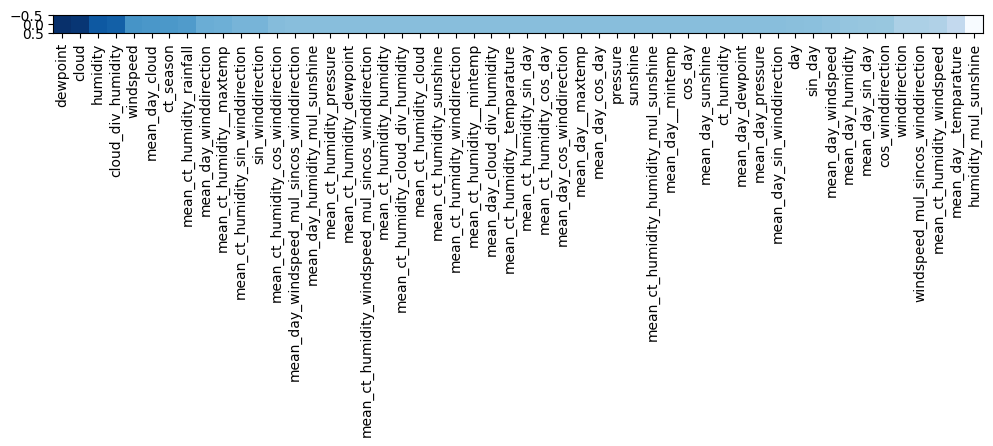

In [110]:
estimator = LogisticRegression(
    # solver='newton-cg',
    # penalty='l2',
    # penalty=None,
    solver='liblinear',
    penalty='l1',
    max_iter=15000,
    class_weight=CLASS_WEIGHTS.to_dict(),
    # n_jobs=-1,
    random_state=13,
)
_ = checkup(estimator, SGD_X, y)
estimator.fit(SGD_X, y)
linear_feature_importances(estimator, figsize=(12, 4))

In [69]:
# estimator = SGDClassifier(
#     loss='log_loss',
#     learning_rate='adaptive',
#     eta0=0.001,
#     alpha=0.001,
#     penalty='l1',
#     max_iter=15000,
#     n_jobs=-1,
#     # early_stopping=True,
#     # class_weight=CLASS_WEIGHTS.to_dict(),
#     shuffle=False,
#     random_state=13,
# )
# _ = checkup(estimator, SGD_X, y)
# estimator.fit(SGD_X, y)
# linear_feature_importances(estimator, figsize=(12, 4))

__overview new features__

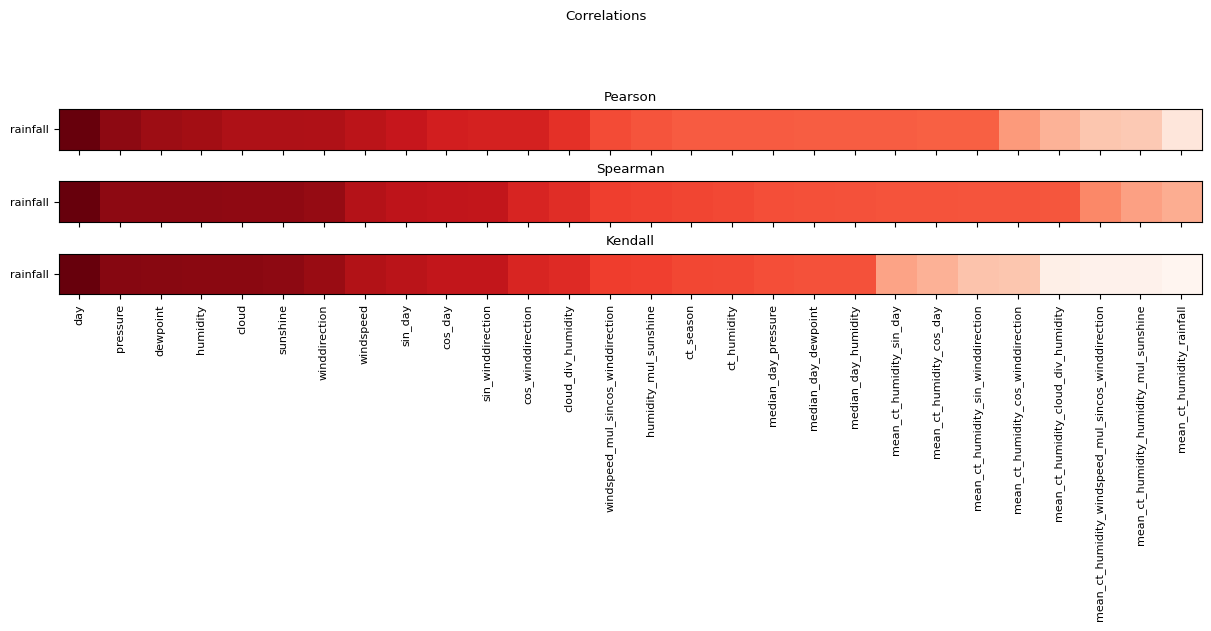

In [89]:
THRESHOLD = 0.075

data = X.copy()
labels = data.columns
data['rainfall'] = y

CORRELATIONS = ('pearson', 'spearman', 'kendall')
# CORRELATIONS = ('pearson', )
# drawing
fig, axes = plt.subplots(len(CORRELATIONS), 1, figsize=(12, 7), sharex=True)
fig.set_layout_engine('compressed')
fig.suptitle('Correlations')
for n, method in enumerate(CORRELATIONS):
    ax = axes[n] if len(CORRELATIONS) > 1 else axes
    ax.set_title(method.capitalize())
    rainfall_corr = data.corr(method)[['rainfall']].drop('rainfall').sort_values('rainfall', ascending=False)
    values = rainfall_corr.values.squeeze()
    filtered = (abs(values) > THRESHOLD)
    ax.imshow(values[filtered].reshape(1, -1), cmap='Reds')
    ax.set_xticks(range(len(labels[filtered])), labels=labels[filtered], rotation=90)
    ax.set_yticks([0], labels=['rainfall'])
plt.show()

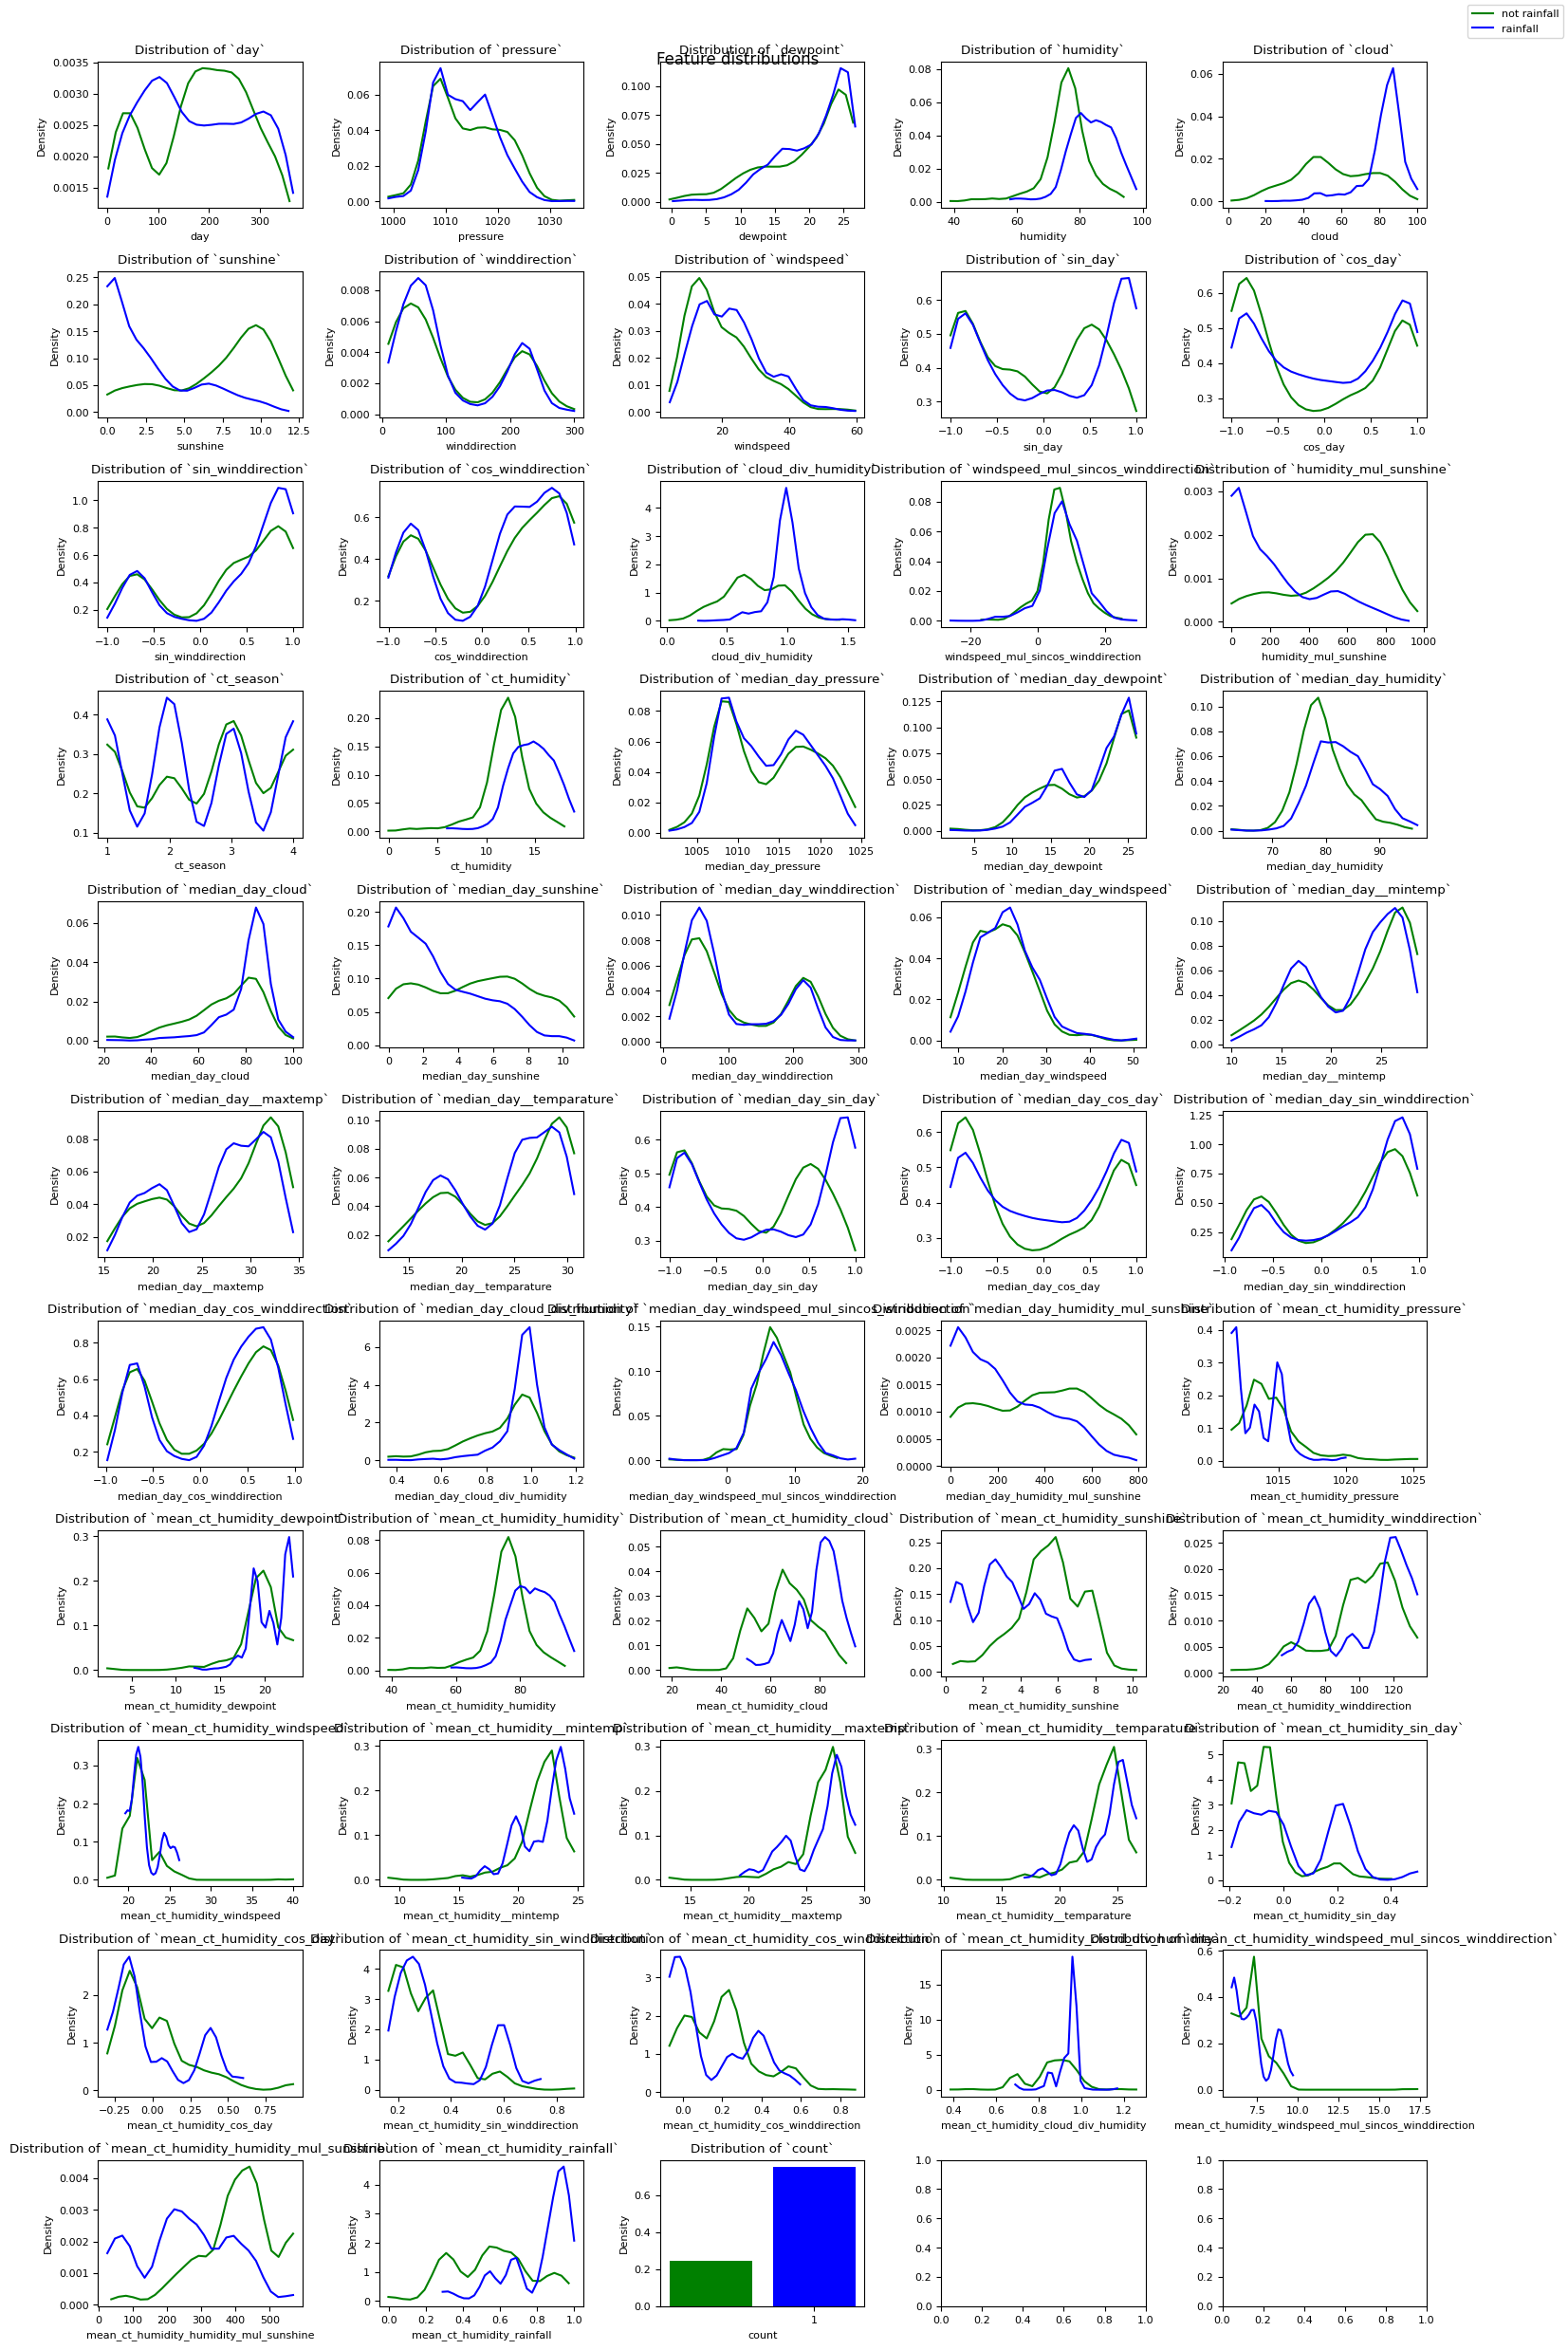

In [90]:
_filter = X.columns
# _filter = X.columns[X.columns.str.match(r'.*_index')]

_X = X[_filter].copy()
_X['rainfall'] = y

COLUMNS = 5
ROWS = max(np.ceil(len(_X.columns) / COLUMNS).astype(int), 2)
SIZE = (COLUMNS * 3, ROWS * 2.25)
plt.rcParams.update({'font.size': 8})

fig, ax = plt.subplots(ROWS, COLUMNS, figsize=SIZE)
fig.suptitle('Feature distributions', fontsize=12)
fig.set_layout_engine('tight')
for n, feature in enumerate(_X.columns):
    row, col = n // COLUMNS, n % COLUMNS
    if feature == 'rainfall':
        feature_overview(ax[row][col], _X.loc[_X.rainfall == 0, feature].value_counts() / _X.shape[0], FigureType.BAR, color='green')
        feature_overview(ax[row][col], _X.loc[_X.rainfall == 1, feature].value_counts() / _X.shape[0], FigureType.BAR, color='blue')
        continue
    feature_overview(ax[row][col], _X.loc[_X.rainfall == 0, feature], FigureType.DENSITY, bins=25, color='green')
    feature_overview(ax[row][col], _X.loc[_X.rainfall == 1, feature], FigureType.DENSITY, bins=25, color='blue')

fig.legend(['not rainfall', 'rainfall'])
plt.show()

__modeling__

In [81]:
# estimator = SGDClassifier(
#     loss='log_loss',
#     learning_rate='adaptive',
#     eta0=0.001,
#     alpha=0.001,
#     penalty='l1',
#     max_iter=15000,
#     n_jobs=-1,
#     # early_stopping=True,
#     # class_weight=CLASS_WEIGHTS.to_dict(),
#     shuffle=False,
#     random_state=13,
# )
# _ = checkup(estimator, SGD_X, y)
# sgd = model = estimator.fit(SGD_X, y)
# linear_feature_importances(model, figsize=(12, 4))

Fold: 0; TRAIN ROC AUC=0.91433; TRAIN f1=0.91703 | VALID ROC AUC=0.88658; VALID f1=0.91034
Fold: 1; TRAIN ROC AUC=0.91873; TRAIN f1=0.91994 | VALID ROC AUC=0.86655; VALID f1=0.90909
Fold: 2; TRAIN ROC AUC=0.91337; TRAIN f1=0.91722 | VALID ROC AUC=0.90002; VALID f1=0.91319
Fold: 3; TRAIN ROC AUC=0.91547; TRAIN f1=0.91942 | VALID ROC AUC=0.89071; VALID f1=0.90598
Fold: 4; TRAIN ROC AUC=0.90801; TRAIN f1=0.91590 | VALID ROC AUC=0.92263; VALID f1=0.91798
Fold: 5; TRAIN ROC AUC=0.90828; TRAIN f1=0.91496 | VALID ROC AUC=0.93236; VALID f1=0.92047
Fold: 6; TRAIN ROC AUC=0.91073; TRAIN f1=0.91645 | VALID ROC AUC=0.91112; VALID f1=0.90476
MEAN: TRAIN ROC AUC=0.91270; TRAIN f1=0.91727 | VALID ROC AUC=0.90142; VALID f1=0.91169


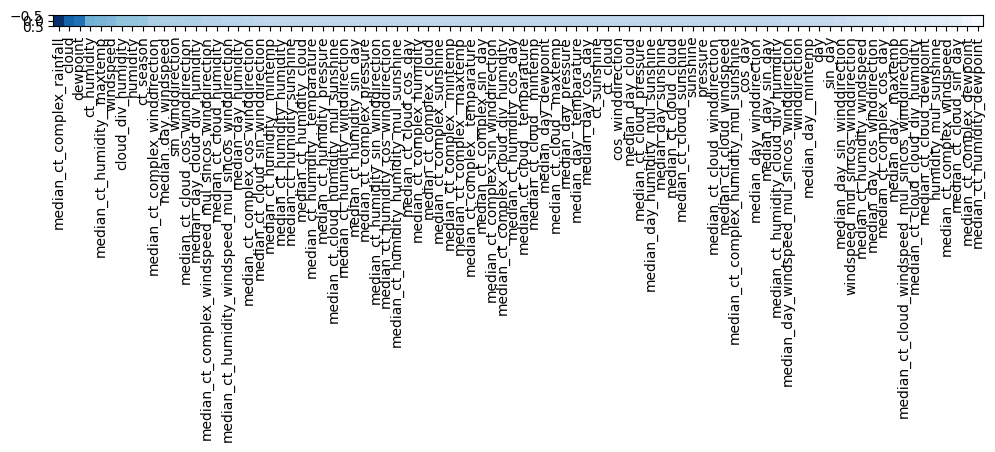

In [104]:
estimator = LogisticRegression(
    # solver='newton-cg',
    # penalty='l2',
    # penalty=None,
    solver='liblinear',
    penalty='l1',
    max_iter=15000,
    class_weight=CLASS_WEIGHTS.to_dict(),
    # n_jobs=-1,
    random_state=13,
)
_ = checkup(estimator, SGD_X, y)
lin = model = estimator.fit(SGD_X, y)
linear_feature_importances(model, figsize=(12, 4))

Fold: 0; TRAIN ROC AUC=0.89227; TRAIN f1=0.89787 | VALID ROC AUC=0.89564; VALID f1=0.89850
Fold: 1; TRAIN ROC AUC=0.89616; TRAIN f1=0.89929 | VALID ROC AUC=0.86532; VALID f1=0.90183
Fold: 2; TRAIN ROC AUC=0.89126; TRAIN f1=0.89802 | VALID ROC AUC=0.89069; VALID f1=0.90256
Fold: 3; TRAIN ROC AUC=0.89340; TRAIN f1=0.89714 | VALID ROC AUC=0.88538; VALID f1=0.89899
Fold: 4; TRAIN ROC AUC=0.89063; TRAIN f1=0.89743 | VALID ROC AUC=0.89940; VALID f1=0.90223
Fold: 5; TRAIN ROC AUC=0.89004; TRAIN f1=0.89708 | VALID ROC AUC=0.90473; VALID f1=0.89967
Fold: 6; TRAIN ROC AUC=0.89140; TRAIN f1=0.90042 | VALID ROC AUC=0.89278; VALID f1=0.87500
MEAN: TRAIN ROC AUC=0.89217; TRAIN f1=0.89818 | VALID ROC AUC=0.89056; VALID f1=0.89697


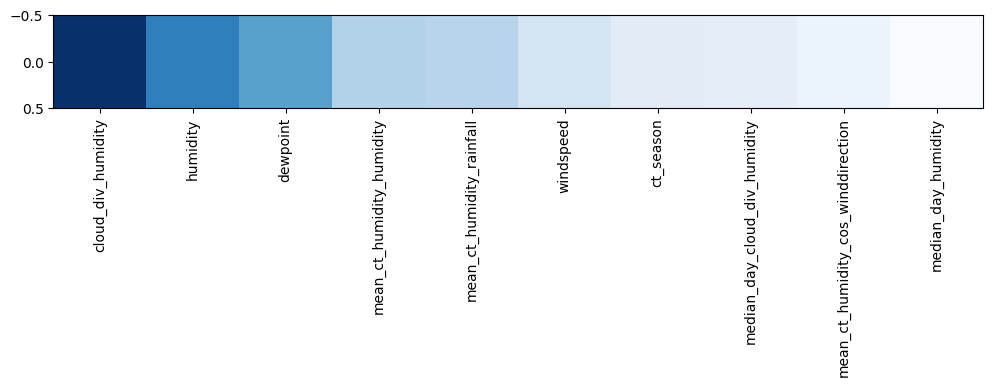

In [45]:
TOP = X.columns[model.coef_.argsort().squeeze()[::-1]][:10]
# TOP
_ = checkup(estimator, SGD_X.loc[:, TOP], y)
lin = deepcopy(estimator).fit(SGD_X.loc[:, TOP], y)
linear_feature_importances(lin, figsize=(12, 4))

__validate on last train year__

In [105]:
estimator = LogisticRegression(
    solver='liblinear',
    penalty='l1',
    max_iter=15000,
    class_weight=CLASS_WEIGHTS.to_dict(),
    # n_jobs=-1,
    random_state=131,
)
Xt, Yt = SGD_X[:1825], y[:1825]
Xv, Yv = SGD_X[1825:], y[1825:]
estimator.fit(Xt, Yt)
pt = estimator.predict_proba(Xt).T[1]
pv = estimator.predict_proba(Xv).T[1]

auc_train = roc_auc_score(Yt, pt)
auc_valid = roc_auc_score(Yv, pv)
f1_train = f1_score(Yt, pt > 0.5)
f1_valid = f1_score(Yv, pv > 0.5)

auc_train, auc_valid, f1_train, f1_valid

(0.9128085169904685,
 0.8960801661794123,
 0.9265064437478231,
 0.9106830122591943)

In [84]:
from modeling import EnsembleMeta

ensemble = EnsembleMeta(LogisticRegression, n_estimators=100, random_state=13)(
    solver='liblinear',
    penalty='l1',
    max_iter=15000,
    class_weight=CLASS_WEIGHTS.to_dict(),
    # n_jobs=-1,
)
_ = checkup(ensemble, SGD_X, y)
ens = model = ensemble.fit(SGD_X, y, verbose=True)

Fold: 0; TRAIN ROC AUC=0.89804; TRAIN f1=0.90238 | VALID ROC AUC=0.89892; VALID f1=0.90944
Fold: 1; TRAIN ROC AUC=0.89731; TRAIN f1=0.90272 | VALID ROC AUC=0.90456; VALID f1=0.90838
Fold: 2; TRAIN ROC AUC=0.89750; TRAIN f1=0.90790 | VALID ROC AUC=0.89873; VALID f1=0.90157
Fold: 3; TRAIN ROC AUC=0.90199; TRAIN f1=0.90510 | VALID ROC AUC=0.86852; VALID f1=0.89189
Fold: 4; TRAIN ROC AUC=0.90096; TRAIN f1=0.90850 | VALID ROC AUC=0.88119; VALID f1=0.88446
Fold: 5; TRAIN ROC AUC=0.89896; TRAIN f1=0.90537 | VALID ROC AUC=0.89192; VALID f1=0.91048
Fold: 6; TRAIN ROC AUC=0.89705; TRAIN f1=0.90445 | VALID ROC AUC=0.89159; VALID f1=0.89796
MEAN: TRAIN ROC AUC=0.89883; TRAIN f1=0.90521 | VALID ROC AUC=0.89077; VALID f1=0.90060


100%|██████████| 100/100 [00:55<00:00,  1.81it/s]


In [106]:
estimator = KNeighborsClassifier(
    # weights='uniform',
    algorithm='ball_tree',
    n_neighbors=50,
    p=1,
    # leaf_size=64,
    n_jobs=-1,
)
_ = checkup(estimator, SGD_X, y)
knn = model = estimator.fit(SGD_X, y)

Fold: 0; TRAIN ROC AUC=0.89820; TRAIN f1=0.91068 | VALID ROC AUC=0.89254; VALID f1=0.90553
Fold: 1; TRAIN ROC AUC=0.90037; TRAIN f1=0.91085 | VALID ROC AUC=0.86526; VALID f1=0.90592
Fold: 2; TRAIN ROC AUC=0.89721; TRAIN f1=0.90958 | VALID ROC AUC=0.90702; VALID f1=0.91336
Fold: 3; TRAIN ROC AUC=0.90321; TRAIN f1=0.91117 | VALID ROC AUC=0.86342; VALID f1=0.90334
Fold: 4; TRAIN ROC AUC=0.89660; TRAIN f1=0.91078 | VALID ROC AUC=0.89033; VALID f1=0.90110
Fold: 5; TRAIN ROC AUC=0.89751; TRAIN f1=0.90713 | VALID ROC AUC=0.90168; VALID f1=0.93023
Fold: 6; TRAIN ROC AUC=0.90126; TRAIN f1=0.91158 | VALID ROC AUC=0.87182; VALID f1=0.89981
MEAN: TRAIN ROC AUC=0.89919; TRAIN f1=0.91025 | VALID ROC AUC=0.88458; VALID f1=0.90847


__wah lol__

Fold: 0; TRAIN ROC AUC=0.89921; TRAIN f1=0.89190 | VALID ROC AUC=0.89880; VALID f1=0.90446
Fold: 1; TRAIN ROC AUC=0.89947; TRAIN f1=0.89190 | VALID ROC AUC=0.90467; VALID f1=0.90129
Fold: 2; TRAIN ROC AUC=0.90092; TRAIN f1=0.89880 | VALID ROC AUC=0.88499; VALID f1=0.88641
Fold: 3; TRAIN ROC AUC=0.90347; TRAIN f1=0.89393 | VALID ROC AUC=0.86762; VALID f1=0.87473
Fold: 4; TRAIN ROC AUC=0.90199; TRAIN f1=0.89478 | VALID ROC AUC=0.88125; VALID f1=0.88435
Fold: 5; TRAIN ROC AUC=0.89947; TRAIN f1=0.89394 | VALID ROC AUC=0.89314; VALID f1=0.89496
Fold: 6; TRAIN ROC AUC=0.90026; TRAIN f1=0.89957 | VALID ROC AUC=0.88048; VALID f1=0.90000
MEAN: TRAIN ROC AUC=0.90068; TRAIN f1=0.89497 | VALID ROC AUC=0.88728; VALID f1=0.89231


100%|██████████| 20/20 [01:00<00:00,  3.02s/it]


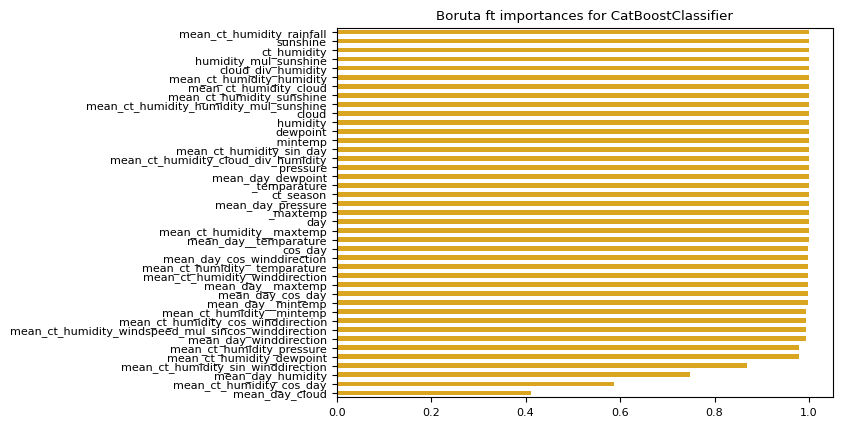

In [401]:
estimator = CatBoostClassifier(
    n_estimators=1500,
    # iterations=1500,
    learning_rate=0.001,
    depth=3,
    class_weights=CLASS_WEIGHTS,
    random_state=19,
    verbose=False,
    allow_writing_files=False,
)
_ = checkup(estimator, X, y, folds=7)
importances = boruta(X, y, estimator.copy(), seed=10, plot=True, alpha=0.95)
catboost = model = estimator.fit(X, y)

__submission__

In [5]:
# SGD
T = pipes['sgd'].transform(test.drop(columns='rainfall'))
rainfall = sgd.predict_proba(T)[:, 1]

if (test['rainfall'] != rainfall).any():
    filecode = uuid.uuid4().hex
    test['rainfall'] = rainfall
    test.reset_index()[['id', 'rainfall']].to_csv(f'{filecode}.csv', index=False)
    print(filecode)

8c2318f4f88b400c8428bb01c480bce6


In [107]:
# logistic regression
T = pipes['sgd'].transform(test.drop(columns='rainfall'))
rainfall = lin.predict_proba(T)[:, 1]

if (test['rainfall'] != rainfall).any():
    filecode = uuid.uuid4().hex
    test['rainfall'] = rainfall
    test.reset_index()[['id', 'rainfall']].to_csv(f'{filecode}.csv', index=False)
    print(filecode)

285b307c3fc74ff4ae032ab79292de40


In [ ]:
# logistic regression ensemble
T = pipes['sgd'].transform(test.drop(columns='rainfall'))
rainfall = ens.predict_proba(T)[:, 1]

if (test['rainfall'] != rainfall).any():
    filecode = uuid.uuid4().hex
    test['rainfall'] = rainfall
    test.reset_index()[['id', 'rainfall']].to_csv(f'{filecode}.csv', index=False)
    print(filecode)

In [72]:
# KNeighbours
T = pipes['sgd'].transform(test.drop(columns='rainfall'))
rainfall = knn.predict_proba(T)[:, 1]

if (test['rainfall'] != rainfall).any():
    filecode = uuid.uuid4().hex
    test['rainfall'] = rainfall
    test.reset_index()[['id', 'rainfall']].to_csv(f'{filecode}.csv', index=False)
    print(filecode)

3f68538198664f9291e4c98f637ce572


In [ ]:
# CatBoost LOL
T = pipes['base'].transform(test.drop(columns='rainfall'))
rainfall = catboost.predict_proba(T)[:, 1]

if (test['rainfall'] != rainfall).any():
    filecode = uuid.uuid4().hex
    test['rainfall'] = rainfall
    test.reset_index()[['id', 'rainfall']].to_csv(f'{filecode}.csv', index=False)
    print(filecode)

b5c1648db89343d191cbd8f500ebbc87


__NN approach__

In [1]:
import torch
import torch.optim as opt
import torch.utils.data
from tqdm import tqdm

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DEVICE

'cuda'

In [4]:
class Dataset(torch.utils.data.Dataset):
    def __init__(self, X, y = None, size: int = 3):
        self.x = X.values.reshape(*X.shape, 1)
        self.y = y.values.reshape(-1, 1) if y is not None else None
        self.size = size

    def __getitem__(self, index):
        """Return item with N previous items"""
        x_bundle, y_bundle = [], []
        for step in range(self.size):
            if (idx := index - step) < 0:
                idx = index
            x_bundle.append(torch.as_tensor(self.x[idx], dtype=torch.float32))
        return (
            torch.concat(x_bundle, dim=-1).reshape(self.size, -1),
            torch.as_tensor(self.y[index], dtype=torch.float32) if self.y is not None else None
        )

    def __len__(self):
        return self.x.shape[0]

dataset = Dataset(SGD_X, y, size=3)
dataset[0][0].shape

torch.Size([3, 55])

In [5]:
class ShowShape(torch.nn.Module):
    def forward(self, X, *args, **kw):
        print(f'{X.shape=}')
        return X


class Model:
    def __init__(
            self,
            days: int,
            features: int,
            hidden_channels: int | None = None,
            linear_channels: int = 64,
            criterion: torch.nn.modules.loss._Loss = torch.nn.BCELoss(),
            optimizer: type[torch.optim.Optimizer] = opt.Adam,
            device: Literal['cpu', 'cuda'] = 'cpu',
            **optimizer_params
    ):
        self.device = device
        self.days = days
        CHANNELS = hidden_channels or (days // 2 + (not days // 2))
        self.model = torch.nn.Sequential(
            # first conv
            torch.nn.Conv1d(days, CHANNELS, kernel_size=days),
            torch.nn.ReLU(),
            torch.nn.MaxPool1d(kernel_size=2),
            # linears
            torch.nn.Flatten(1),
            torch.nn.Linear(CHANNELS * ((features - days + 1) // 2), linear_channels // 2),

            # # first conv
            # torch.nn.Conv1d(days, CHANNELS, kernel_size=2 if days > 1 else 1),
            # torch.nn.ReLU(),
            # torch.nn.MaxPool1d(kernel_size=2),
            # # second conv
            # torch.nn.Conv1d(CHANNELS, days, kernel_size=days - 1),
            # torch.nn.ReLU(),
            # torch.nn.MaxPool1d(kernel_size=2),
            # # linears
            # torch.nn.Flatten(1),
            # torch.nn.Linear(days * ((((features - days + 1) // 2) - (days > 2)) // 2), linear_channels // 2),

            torch.nn.ReLU(),
            torch.nn.Dropout(0.25),
            torch.nn.Linear(linear_channels // 2, linear_channels // 4),
            torch.nn.ReLU(),
            torch.nn.Linear(linear_channels // 4, 1),
            torch.nn.Sigmoid(),
        )
        self.model.compile()
        self.optimizer = optimizer(self.model.parameters(), **optimizer_params)
        self.criterion = criterion

    def fit(self, X, y, epochs: int = 5, batch_size: int = 32, verbose: bool = True):
        # make dataset loader
        dataset = Dataset(X, y, size=self.days)
        loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size)
        # fit
        self.model.to(self.device)
        self.model.train()
        for ep in range(epochs):
            sum_loss, items = 0.0, 0
            if verbose:
                pbar = tqdm(enumerate(loader), total=len(loader), desc=f'Epoch {ep + 1}/{epochs}')
            else:
                pbar = enumerate(loader)
            for i, batch in pbar:
                inputs, labels = batch[0].to(self.device), batch[1].to(self.device)
                self.optimizer.zero_grad()
                outputs = self.model(inputs)
                loss = self.criterion(outputs, labels)
                loss.backward()
                self.optimizer.step()
                # calc loss
                sum_loss += loss.item()
                items += len(labels)
                if verbose and isinstance(pbar, tqdm):
                    pbar.set_postfix({'cumulative loss per item': sum_loss / items})
        self.model.eval()

    def predict_proba(self, X):
        assert self.model is not None, 'Model is not trained'
        # make dataset loader
        dataset = Dataset(X, y, size=self.days)
        loader = torch.utils.data.DataLoader(dataset, batch_size=X.shape[0])
        predictions = self.model.forward(next(iter(loader))[0])
        return predictions.detach()

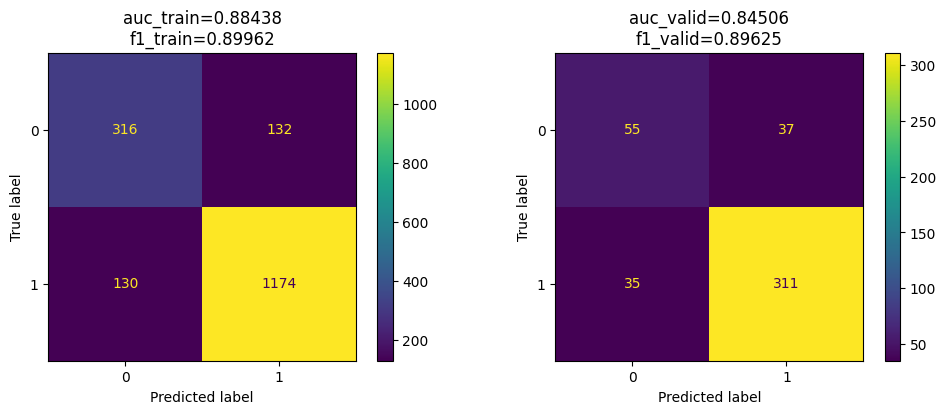

In [42]:
torch.manual_seed(11)
DAYS = 3
dataset = Dataset(SGD_X, y, size=DAYS)

model = Model(
    days=DAYS,
    features=SGD_X.shape[1],
    hidden_channels=1,
    linear_channels=72,
    criterion=torch.nn.BCELoss(),
    # criterion=torch.nn.HuberLoss(delta=0.8),
    lr=0.01,
)
X_train, X_valid, y_train, y_valid = train_test_split(SGD_X, y, test_size=0.2, shuffle=False, random_state=19)
model.fit(X_train, y_train, epochs=50, batch_size=1024, verbose=False)

# predicting
y_pred_train = model.predict_proba(X_train)
y_pred_valid = model.predict_proba(X_valid)
# scoring
auc_train = roc_auc_score(y_train, y_pred_train)
auc_valid = roc_auc_score(y_valid, y_pred_valid)
f1_train = f1_score(y_train, y_pred_train > 0.5)
f1_valid = f1_score(y_valid, y_pred_valid > 0.5)
# drawing
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(y_train, y_pred_train.numpy() > 0.5, ax=ax[0])
ConfusionMatrixDisplay.from_predictions(y_valid, y_pred_valid.numpy() > 0.5, ax=ax[1])
ax[0].set_title(f'{auc_train=:.5f}\n{f1_train=:.5f}')
ax[1].set_title(f'{auc_valid=:.5f}\n{f1_valid=:.5f}')
plt.show()

__NN cross validation__

In [11]:
def nn_checkup(estimator_base, X, y, folds=7, **fit_params):
    metrics = []
    kf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=19)
    estimator = estimator_base
    for f, (train, valid) in enumerate(kf.split(X, y)):
        estimator = deepcopy(estimator_base)
        estimator.fit(X.loc[train], y[train], **fit_params)

        pt = estimator.predict_proba(X.loc[train]).numpy()
        pv = estimator.predict_proba(X.loc[valid]).numpy()

        auc_train = roc_auc_score(y[train], pt)
        auc_valid = roc_auc_score(y[valid], pv)
        f1_train = f1_score(y[train], pt > 0.5)
        f1_valid = f1_score(y[valid], pv > 0.5)
        metrics.append((auc_train, f1_train, auc_valid, f1_valid))
        print(f'Fold: {f}; TRAIN ROC AUC={auc_train:.5f}; TRAIN f1={f1_train:.5f} | VALID ROC AUC={auc_valid:.5f}; VALID f1={f1_valid:.5f}')
    means = np.mean(metrics, axis=0)
    print(f'MEAN: TRAIN ROC AUC={means[0]:.5f}; TRAIN f1={means[1]:.5f} | VALID ROC AUC={means[2]:.5f}; VALID f1={means[3]:.5f}')
    return estimator


torch.manual_seed(11)
_ = nn_checkup(model, SGD_X, y, epochs=10, batch_size=512, verbose=False)

Fold: 0; TRAIN ROC AUC=0.98836; TRAIN f1=0.96628 | VALID ROC AUC=0.96456; VALID f1=0.94456
Fold: 1; TRAIN ROC AUC=0.98746; TRAIN f1=0.96818 | VALID ROC AUC=0.96484; VALID f1=0.94168
Fold: 2; TRAIN ROC AUC=0.98681; TRAIN f1=0.96375 | VALID ROC AUC=0.97001; VALID f1=0.95781
Fold: 3; TRAIN ROC AUC=0.98711; TRAIN f1=0.96469 | VALID ROC AUC=0.97386; VALID f1=0.94194
Fold: 4; TRAIN ROC AUC=0.98554; TRAIN f1=0.96729 | VALID ROC AUC=0.98052; VALID f1=0.95258
Fold: 5; TRAIN ROC AUC=0.98709; TRAIN f1=0.96424 | VALID ROC AUC=0.96645; VALID f1=0.95616
Fold: 6; TRAIN ROC AUC=0.98693; TRAIN f1=0.96415 | VALID ROC AUC=0.96104; VALID f1=0.94348
MEAN: TRAIN ROC AUC=0.98704; TRAIN f1=0.96551 | VALID ROC AUC=0.96875; VALID f1=0.94831


__final fit__

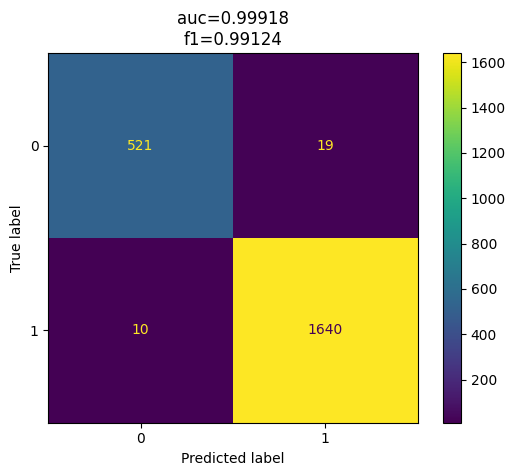

In [12]:
torch.manual_seed(11)
DAYS = 2
dataset = Dataset(SGD_X, y, size=DAYS)

cnn = model = Model(
    days=DAYS,
    features=SGD_X.shape[1],
    hidden_channels=8,
    linear_channels=96,
    criterion=torch.nn.BCELoss(),
    lr=0.01,
)
model.fit(SGD_X, y, epochs=250, batch_size=1024, verbose=False)

predictions = model.predict_proba(SGD_X)
auc = roc_auc_score(y, predictions)
f1 = f1_score(y, predictions > 0.5)
fix, ax = plt.subplots(1, 1)
ConfusionMatrixDisplay.from_predictions(y, predictions.numpy() > 0.5, ax=ax)
ax.set_title(f'{auc=:.5f}\n{f1=:.5f}')
plt.show()

In [13]:
# CNN
T = pipes['sgd'].transform(test.drop(columns='rainfall'))
rainfall = cnn.predict_proba(T)

if (test['rainfall'] != rainfall).any():
    filecode = uuid.uuid4().hex
    test['rainfall'] = rainfall
    test.reset_index()[['id', 'rainfall']].to_csv(f'{filecode}.csv', index=False)
    print(filecode)

9c500742969546809c17128740a06861


__mix predictions__

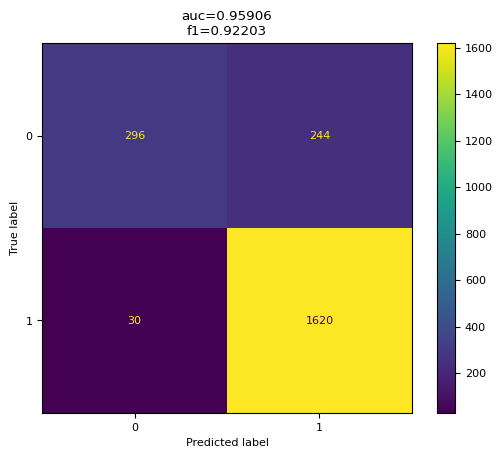

In [307]:
weights = np.array([0.3, 0.4, 0.3]).reshape(3, 1)

predictions = sum(weights * np.array((
    sgd.predict_proba(SGD_X)[:, 1],
    lin.predict_proba(SGD_X)[:, 1],
    # knn.predict_proba(SGD_X)[:, 1],
    # catboost.predict_proba(X)[:, 1],
    cnn.predict_proba(SGD_X).numpy()[:, 0],
)))

auc = roc_auc_score(y, predictions)
f1 = f1_score(y, predictions > 0.5)
fix, ax = plt.subplots(1, 1)
ConfusionMatrixDisplay.from_predictions(y, predictions > 0.5, ax=ax)
ax.set_title(f'{auc=:.5f}\n{f1=:.5f}')
plt.show()

In [36]:
T1 = pipes['base'].transform(test.drop(columns='rainfall'))
T2 = pipes['sgd'].transform(test.drop(columns='rainfall'))

rainfall = sum(weights * np.array((
    sgd.predict_proba(T2)[:, 1],
    lin.predict_proba(T2)[:, 1],
    knn.predict_proba(T2)[:, 1],
    # catboost.predict_proba(T1)[:, 1],
    cnn.predict_proba(T2).numpy()[:, 0]
)))
if (test['rainfall'] != rainfall).any():
    filecode = uuid.uuid4().hex
    test['rainfall'] = rainfall
    test.reset_index()[['id', 'rainfall']].to_csv(f'{filecode}.csv', index=False)
    print(filecode)

c31d0ac049f346939ce388c0c5eaa524


In [ ]:
#